# Interactions

In [2]:
# importing libraries
import pandas as pd
from pathlib import Path
pd.set_option('display.max_columns', None)

In [3]:
# paths
INTERIM = Path("../data/interim")

In [4]:
inter = pd.read_parquet(INTERIM / "interactions.parquet")

In [5]:
inter.head()

,user_id,is_read,rating,is_reviewed,work_id
0,0,1,5,0,135328
1,0,1,5,1,2305997
2,0,1,5,0,89369
3,0,1,5,0,1699340
4,0,1,5,0,41335427


In [6]:
inter.shape

(105744280, 5)

In [7]:
print(inter.rating.value_counts().sort_index().to_string())

rating
0     7042443
1     1873601
2     5699092
3    21791957
4    35518845
5    33818342


In [8]:
n_users = inter.user_id.nunique()
n_items = inter.work_id.nunique()

print(f"users    {n_users:,}")
print(f"works    {n_items:,}")
print(f"density  {len(inter) / (n_users * n_items):.6%}")

users    827,743
works    996,177
density  0.012824%


In [17]:
per_item = inter.groupby("work_id").size()

for k in [1, 5, 10, 20, 50, 100]:
    print(f">= {k:>4} interactions: {per_item.ge(k).sum():>8,}")

>=    1 interactions:  996,177
>=    5 interactions:  619,247
>=   10 interactions:  451,915
>=   20 interactions:  308,905
>=   50 interactions:  173,074
>=  100 interactions:  106,640


In [9]:
per_user = inter.groupby("user_id").size()

print(per_user.describe().round(1).to_string())
for k in [1, 5, 10, 20, 50]:
    print(f"users with >= {k:>3}  {per_user.ge(k).sum():>9,}  ({per_user.ge(k).mean():.1%})")

count    827743.0
mean        127.8
std         235.2
min           1.0
25%          21.0
50%          54.0
75%         141.0
max       36069.0
users with >=   1    827,743  (100.0%)
users with >=   5    752,821  (90.9%)
users with >=  10    700,843  (84.7%)
users with >=  20    632,550  (76.4%)
users with >=  50    435,386  (52.6%)


In [18]:
keep_i = per_item[per_item >= 20].index
keep_u = per_user[per_user >= 10].index

dense = inter[inter.work_id.isin(keep_i) & inter.user_id.isin(keep_u)]

print(f"{len(dense):,} interactions")
print(f"{dense.user_id.nunique():,} users, {dense.work_id.nunique():,} works")
print(f"density {len(dense) / (dense.user_id.nunique() * dense.work_id.nunique()):.4%}")

101,389,728 interactions
700,797 users, 308,905 works
density 0.0468%


In [10]:
per_item = inter.groupby("work_id").size()

print(per_item.describe().round(1).to_string())
for k in [1, 5, 10, 50, 100]:
    print(f"works with >= {k:>4}  {per_item.ge(k).sum():>9,}  ({per_item.ge(k).mean():.1%})")

count    996177.0
mean        106.2
std        1467.6
min           1.0
25%           3.0
50%           8.0
75%          28.0
max      321402.0
works with >=    1    996,177  (100.0%)
works with >=    5    619,247  (62.2%)
works with >=   10    451,915  (45.4%)
works with >=   50    173,074  (17.4%)
works with >=  100    106,640  (10.7%)


In [11]:
print(inter.rating.value_counts().sort_index().to_string())
print(f"\nzero (unrated): {inter.rating.eq(0).mean():.1%}")

rating
0     7042443
1     1873601
2     5699092
3    21791957
4    35518845
5    33818342

zero (unrated): 6.7%


In [19]:
print(f"books                 {inter.work_id.nunique():,}")
print(f"users                 {inter.user_id.nunique():,}")
print(f"avg ratings per book  {len(inter) / inter.work_id.nunique():.1f}")
print(f"avg books per user    {len(inter) / inter.user_id.nunique():.1f}")

books                 996,177
users                 827,743
avg ratings per book  106.2
avg books per user    127.8


In [12]:
top = per_item.sort_values(ascending=False)
total = per_item.sum()

for k in [100, 1000, 10000]:
    print(f"top {k:>6,} works = {top.head(k).sum() / total:.1%} of interactions")

top    100 works = 10.3% of interactions
top  1,000 works = 29.0% of interactions
top 10,000 works = 57.9% of interactions


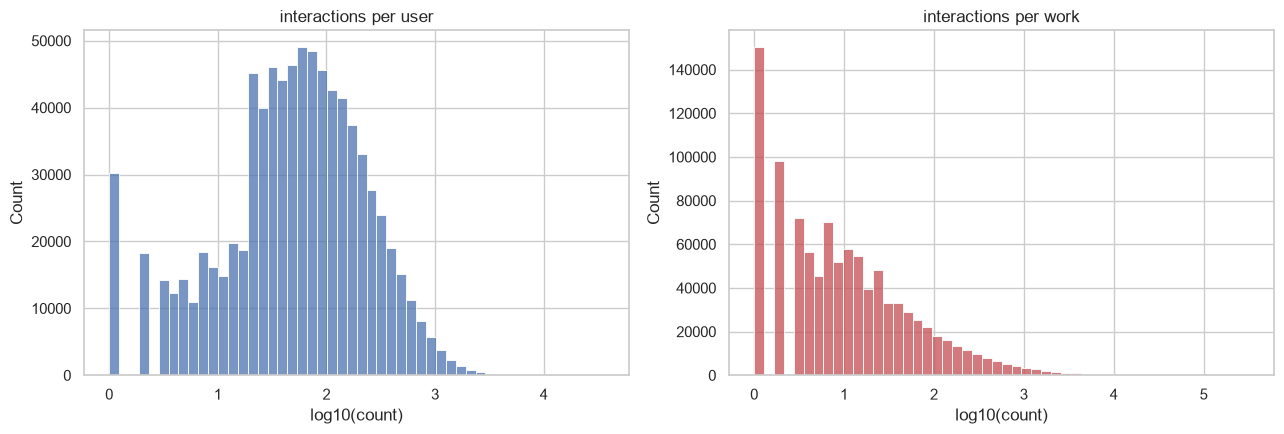

In [13]:
import numpy as np, matplotlib.pyplot as plt, seaborn as sns

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(np.log10(per_user), bins=50, ax=ax[0])
ax[0].set_title("interactions per user")
ax[0].set_xlabel("log10(count)")

sns.histplot(np.log10(per_item), bins=50, ax=ax[1], color="#C44E52")
ax[1].set_title("interactions per work")
ax[1].set_xlabel("log10(count)")

plt.tight_layout()

In [15]:
books = pd.read_parquet(
    INTERIM / "english_works_all.parquet",
    columns=["work_id", "title", "authors", "genres", "ratings_total"],
)

top20 = per_item.nlargest(20).rename("n").reset_index()
top20.merge(books[["work_id", "title", "ratings_total"]], on="work_id", how="left")

,work_id,n,title,ratings_total
0,4640799,321402,Harry Potter and the Sorcerer's Stone (Harry P...,4970387
1,2792775,296446,"The Hunger Games (The Hunger Games, #1)",5064668
2,3212258,239141,"Twilight (Twilight, #1)",3991256
3,3275794,216614,To Kill a Mockingbird,3399207
4,2402163,200442,Harry Potter and the Prisoner of Azkaban (Harr...,2016007
5,6231171,199705,Harry Potter and the Chamber of Secrets (Harry...,1950555
6,3046572,191584,Harry Potter and the Goblet of Fire (Harry Pot...,1909895
7,245494,188565,The Great Gatsby,2841340
8,6171458,188466,"Catching Fire (The Hunger Games, #2)",2013187
9,2809203,184971,Harry Potter and the Order of the Phoenix (Har...,1873246


In [16]:
top20 = per_item.nlargest(20).rename("n").reset_index()
top20.merge(books[["work_id", "title", "ratings_total"]], on="work_id", how="left")

,work_id,n,title,ratings_total
0,4640799,321402,Harry Potter and the Sorcerer's Stone (Harry P...,4970387
1,2792775,296446,"The Hunger Games (The Hunger Games, #1)",5064668
2,3212258,239141,"Twilight (Twilight, #1)",3991256
3,3275794,216614,To Kill a Mockingbird,3399207
4,2402163,200442,Harry Potter and the Prisoner of Azkaban (Harr...,2016007
5,6231171,199705,Harry Potter and the Chamber of Secrets (Harry...,1950555
6,3046572,191584,Harry Potter and the Goblet of Fire (Harry Pot...,1909895
7,245494,188565,The Great Gatsby,2841340
8,6171458,188466,"Catching Fire (The Hunger Games, #2)",2013187
9,2809203,184971,Harry Potter and the Order of the Phoenix (Har...,1873246
